In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import griddata

In [ ]:


data_path = os.path.join('.', 'data', 'Ihuaenyi_concentration_data.csv')
df = pd.read_csv(data_path)

print(df['X  [𝜇m]'].min())
print(df['X  [𝜇m]'].max())
print(df['Y  [𝜇m]'].min())
print(df['Y  [𝜇m]'].max())


data_path2 = os.path.join('.', 'data', 'Ihuaenyi_strain_data.csv')
df2 = pd.read_csv(data_path2)



0.603704672
22.00523628
3.153466201
40.00393316


KeyError: 'X  [𝜇m]'

<class 'pandas.Series'>


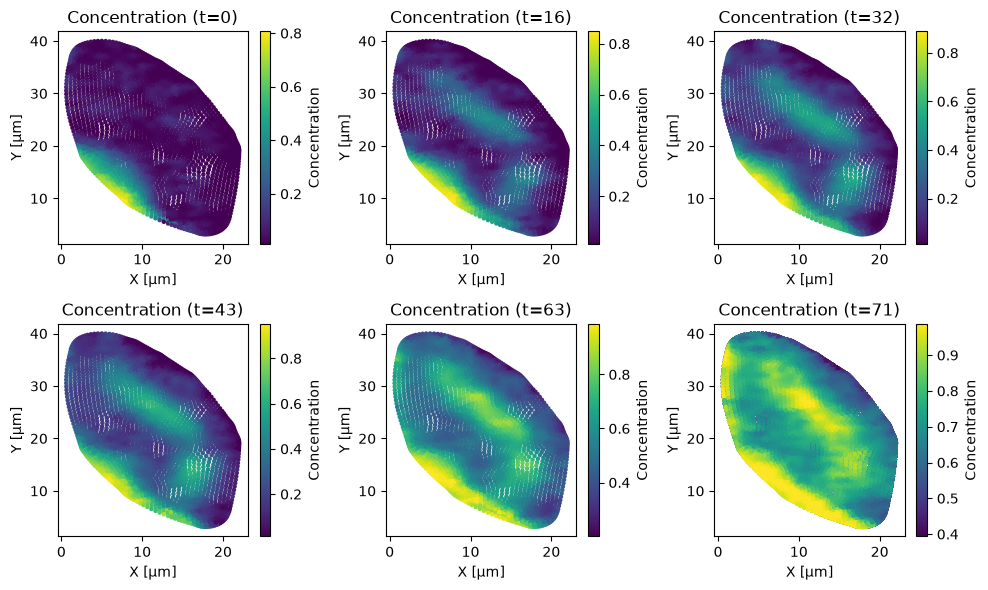

In [3]:
data_path = os.path.join('.', 'data', 'Ihuaenyi_concentration_data.csv')
df = pd.read_csv(data_path)
times = [0, 16, 32, 43, 63, 71]
x = df.iloc[:,0]
y = df.iloc[:,1]
print(type(x))

fig, axs = plt.subplots(2, 3, figsize=(10, 6))
for i in range(2):
    for j in range(3):
        z = df.iloc[:, i*3+2+j]
        scatter = plt.scatter(x, y, c=z, cmap='viridis', s=5)
        axs[i, j].scatter(x, y, c=z, cmap='viridis', s=5)
        axs[i, j].set_title(f'Concentration (t={times[i*3 + j]})')
        axs[i, j].set_xlabel('X [μm]')
        axs[i, j].set_ylabel('Y [μm]')
        cbar = fig.colorbar(scatter, ax=axs[i, j])
        cbar.set_label('Concentration')
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join('.', 'results', 'v1')
PLOTS_DIR = os.path.join(RESULTS_DIR, 'plots')
DATA_PATH = os.path.join('.', 'data', 'Ihuaenyi_concentration_data.csv')
TIMES = [0, 16,32, 43, 63, 71]

def plot_pred(field, results_dir=RESULTS_DIR, plots_dir=PLOTS_DIR):
    if field not in ('k', 'j_0'):
        raise ValueError('Invalid field requested')
    df_c = pd.read_csv(DATA_PATH)
    df_field = pd.read_csv(os.path.join(results_dir, f'pred_{field}.csv'))
    df_over_c = pd.DataFrame()
    df_over_c['concentration']
    for time in TIMES:
        df_over_c['concentration'] = df_over_c['concentration'].concat(df_c[f'C [t={time}]'])
        df_over_c['{field}(c)'] = df_over_c['{field}(c)'].concat(df_field[f'pred_{field}(time)'])
    
    df_over_c.to_csv(os.path.join(RESULTS_DIR, f'{field}_over_c.csv'))

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.semilogy(df_over_c['concentration'], df_over_c[f'{field}(c)'])
    ax.set_xlabel('Concentration')
    ax.set_ylabel(f'{field}(c)')
    #ax.set_title('Per-Epoch Loss: Allen–Cahn PINN v1')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    fig.tight_layout()
    os.makedirs(plots_dir, exist_ok=True)
    fig.savefig(os.path.join(plots_dir, f'{field}_over_c.png'), dpi=150)
    plt.close(fig)

    